In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/boshramahbub/malvies-data/train_split.csv
/kaggle/input/datasets/boshramahbub/malvies-data/test_split.csv
/kaggle/input/datasets/boshramahbub/malvies-data/internal_validation_split.csv
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/val/Amonetize/b653a24164f3a05bfe126bf84eac87390634b6e7resized_image.png
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/val/Amonetize/f889e45de944c904dec35c35ad837e76cc093f5cresized_image.png
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/val/Amonetize/c52ba533b2b9c7daaa9af536f964eee85f7db3d3resized_image.png
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/val/Amonetize/bb7fb026f8994a52af7175816d2736df99c74b65resized_image.png
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/val/Amonetize/e7aa6fa55b68c5c75c335499a06ec457e2f6735bresized_image.png
/kaggle/input/datasets/sohamkuma

In [37]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [38]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/boshramahbub/malvies-data/train_split.csv
/kaggle/input/datasets/boshramahbub/malvies-data/test_split.csv
/kaggle/input/datasets/boshramahbub/malvies-data/internal_validation_split.csv


In [39]:
from pathlib import Path
import pandas as pd

INPUT_ROOT = Path("/kaggle/input")


def find_file(filename):
    matches = list(INPUT_ROOT.rglob(filename))

    if not matches:
        raise FileNotFoundError(f"{filename} not found")

    return matches[0]


TRAIN_CSV = find_file("train_split.csv")
VAL_CSV = find_file("internal_validation_split.csv")
TEST_CSV = find_file("test_split.csv")

print("Train CSV:", TRAIN_CSV)
print("Validation CSV:", VAL_CSV)
print("Test CSV:", TEST_CSV)

Train CSV: /kaggle/input/datasets/boshramahbub/malvies-data/train_split.csv
Validation CSV: /kaggle/input/datasets/boshramahbub/malvies-data/internal_validation_split.csv
Test CSV: /kaggle/input/datasets/boshramahbub/malvies-data/test_split.csv


In [40]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training images:", len(train_df))
print("Internal validation images:", len(val_df))
print("Final test images:", len(test_df))

print("\nColumns:")
print(train_df.columns.tolist())

display(train_df.head())

Training images: 6999
Internal validation images: 1751
Final test images: 3477

Columns:
['filepath', 'relative_path', 'class_name', 'label', 'label_id', 'hash']


,filepath,relative_path,class_name,label,label_id,hash
0,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/490414f8e646fbad11d392106f38ec9...,Adposhel,Adposhel,0,5eabfcd800292738bcb70f818a8b9319
1,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/96022ca14d5b070258c892ebf7153e0...,Adposhel,Adposhel,0,55951eca5fdd3aa764b096cba7e06ab9
2,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/95c6546ecaf79394a4ace0512a52057...,Adposhel,Adposhel,0,bc1bd6f2cd6125334409930bba59d7a3
3,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/774964c435f7b10f3227fceebfad605...,Adposhel,Adposhel,0,66ad26b2bd35d5017c54210bcc0e03e1
4,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/91a0467c07dbb3282e07dc0a214846a...,Adposhel,Adposhel,0,c7baaebfdcf4ca3c1561105727feefb1


In [41]:
image_files = (
    list(INPUT_ROOT.rglob("*.png"))
    + list(INPUT_ROOT.rglob("*.jpg"))
    + list(INPUT_ROOT.rglob("*.jpeg"))
)

print("Total original images found:", len(image_files))

if image_files:
    print("Example image:", image_files[0])
else:
    print("Original MaleVis images are not attached yet.")

Total original images found: 14226
Example image: /kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/val/Amonetize/b653a24164f3a05bfe126bf84eac87390634b6e7resized_image.png


In [42]:
# Show the available columns
print("Train columns:", train_df.columns.tolist())

# Automatically identify important columns
PATH_COL = next(
    col for col in ["filepath", "file_path", "path", "relative_path"]
    if col in train_df.columns
)

LABEL_COL = next(
    col for col in ["class_name", "label", "class"]
    if col in train_df.columns
)

print("Path column:", PATH_COL)
print("Label column:", LABEL_COL)

Train columns: ['filepath', 'relative_path', 'class_name', 'label', 'label_id', 'hash']
Path column: filepath
Label column: class_name


In [43]:
from pathlib import Path

for split_name, dataframe in {
    "Train": train_df,
    "Internal Validation": val_df,
    "Test": test_df
}.items():

    missing_files = dataframe[PATH_COL].apply(
        lambda path: not Path(str(path)).exists()
    ).sum()

    print(f"\n{split_name}")
    print("Images:", len(dataframe))
    print("Classes:", dataframe[LABEL_COL].nunique())
    print("Missing files:", missing_files)
    print(
        "Contains Other:",
        dataframe[LABEL_COL]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("other")
        .any()
    )


Train
Images: 6999
Classes: 25
Missing files: 0
Contains Other: False

Internal Validation
Images: 1751
Classes: 25
Missing files: 0
Contains Other: False

Test
Images: 3477
Classes: 25
Missing files: 0
Contains Other: False


In [63]:
# =====================================
# 1. MobileNetV2 Configuration
# =====================================

import tensorflow as tf
import numpy as np
import pandas as pd


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 25
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE


tf.keras.utils.set_random_seed(SEED)


# Data augmentation for MobileNetV2
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor=0.03,
            seed=SEED
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            seed=SEED
        ),
    ],
    name="mobilenetv2_augmentation"
)

In [65]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear"
    )

    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.int32)

    return image, label

In [67]:
def create_mobilenet_dataset(
    dataframe,
    training=False
):

    filepaths = dataframe["filepath"].astype(str).values
    labels = dataframe["label_id"].astype(np.int32).values


    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )


    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )


    # Load images
    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )


    # Apply MobileNetV2 preprocessing
    dataset = dataset.map(
        lambda images, labels: (
            tf.keras.applications.mobilenet_v2.preprocess_input(images),
            labels
        ),
        num_parallel_calls=AUTOTUNE
    )


    # Batch
    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )


    # Augmentation only for training
    if training:
        dataset = dataset.map(
            lambda images, labels: (
                data_augmentation(
                    images,
                    training=True
                ),
                labels
            ),
            num_parallel_calls=AUTOTUNE
        )


    dataset = dataset.prefetch(
        AUTOTUNE
    )


    return dataset

In [68]:
# =====================================
# Create MobileNetV2 datasets
# =====================================

mobilenet_train_ds = create_mobilenet_dataset(
    train_df,
    training=True
)

mobilenet_val_ds = create_mobilenet_dataset(
    val_df,
    training=False
)

mobilenet_test_ds = create_mobilenet_dataset(
    test_df,
    training=False
)

print("MobileNetV2 datasets created successfully.")

MobileNetV2 datasets created successfully.


In [69]:
for images, labels in mobilenet_train_ds.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Images: (32, 224, 224, 3)
Labels: (32,)


In [70]:
train_images, train_labels = next(
    iter(mobilenet_train_ds)
)

print("Image batch shape:", train_images.shape)
print("Label batch shape:", train_labels.shape)

print("Image dtype:", train_images.dtype)
print("Label dtype:", train_labels.dtype)

print("Minimum pixel value:",
      float(tf.reduce_min(train_images)))

print("Maximum pixel value:",
      float(tf.reduce_max(train_images)))

print("Minimum label:",
      int(tf.reduce_min(train_labels)))

print("Maximum label:",
      int(tf.reduce_max(train_labels)))

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Minimum pixel value: -1.0
Maximum pixel value: 0.9836822748184204
Minimum label: 1
Maximum label: 23


In [71]:
print("Train label range:",
      train_df["label_id"].min(),
      "to",
      train_df["label_id"].max())

print("Validation label range:",
      val_df["label_id"].min(),
      "to",
      val_df["label_id"].max())

print("Test label range:",
      test_df["label_id"].min(),
      "to",
      test_df["label_id"].max())

Train label range: 0 to 24
Validation label range: 0 to 24
Test label range: 0 to 24


In [72]:
import tensorflow as tf
from tensorflow.keras import layers, Model


IMG_SHAPE = (224, 224, 3)
NUM_CLASSES = 25


mobilenet_base = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SHAPE
)


# Stage 1: freeze ImageNet backbone
mobilenet_base.trainable = False


inputs = layers.Input(
    shape=IMG_SHAPE,
    name="input_image"
)


x = mobilenet_base(
    inputs,
    training=False
)


x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)


x = layers.Dropout(
    0.4,
    name="dropout"
)(x)


outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="class_predictions"
)(x)


mobilenet_v2_model = Model(
    inputs,
    outputs,
    name="MaleVis_MobileNetV2"
)


mobilenet_v2_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)


mobilenet_v2_model.summary()

Model: "MaleVis_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_predictions (Dense)       │ (None, 25)             │        32,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,290,009 (8.74 MB)

 Trainable params: 32,025 (125.10 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [73]:
# =====================================
# Experiment Setup and Model Saving Paths
# =====================================

from pathlib import Path
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight


OUTPUT_DIR = Path("/kaggle/working/mobilenetv2_outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


STAGE1_MODEL_PATH = OUTPUT_DIR / "mobilenetv2_frozen_best.keras"

In [76]:
# =====================================
# Calculate Class Weights for MALVIES
# =====================================

train_labels_array = train_df["label_id"].astype(int).values

class_ids = np.arange(NUM_CLASSES)


weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=train_labels_array
)


class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, weights)
}


print("Class weights:")

for class_id, weight in class_weights.items():
    print(f"Class {class_id:2d}: {weight:.4f}")

Class weights:
Class  0: 0.9999
Class  1: 0.9999
Class  2: 0.9999
Class  3: 0.9963
Class  4: 0.9999
Class  5: 0.9999
Class  6: 0.9999
Class  7: 0.9999
Class  8: 0.9999
Class  9: 0.9999
Class 10: 1.0071
Class 11: 0.9999
Class 12: 0.9999
Class 13: 0.9999
Class 14: 0.9999
Class 15: 0.9999
Class 16: 0.9999
Class 17: 0.9999
Class 18: 0.9999
Class 19: 0.9999
Class 20: 0.9999
Class 21: 0.9999
Class 22: 0.9999
Class 23: 0.9999
Class 24: 0.9999


In [77]:
# =====================================
# Stage 1 Training Callbacks
# =====================================

stage1_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE1_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),


    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),


    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [78]:
# =====================================
# Stage 1: Train Frozen MobileNetV2
# =====================================

stage1_start_time = time.time()


mobilenet_stage1_history = mobilenet_v2_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=stage1_callbacks,
    verbose=1
)


stage1_training_time = time.time() - stage1_start_time


print(
    f"\nStage 1 training time: "
    f"{stage1_training_time / 60:.2f} minutes"
)


print("Best frozen model saved at:")
print(STAGE1_MODEL_PATH)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.4613 - loss: 2.0669
Epoch 1: val_loss improved from None to 1.15483, saving model to /kaggle/working/mobilenetv2_outputs/mobilenetv2_frozen_best.keras

Epoch 1: finished saving model to /kaggle/working/mobilenetv2_outputs/mobilenetv2_frozen_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 67s 263ms/step - accuracy: 0.6322 - loss: 1.4152 - val_accuracy: 0.6556 - val_loss: 1.1548 - learning_rate: 0.0010
Epoch 2/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7901 - loss: 0.8061
Epoch 2: val_loss improved from 1.15483 to 1.03549, saving model to /kaggle/working/mobilenetv2_outputs/mobilenetv2_frozen_best.keras

Epoch 2: finished saving model to /kaggle/working/mobilenetv2_outputs/mobilenetv2_frozen_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 213ms/step - accuracy: 0.8041 - loss: 0.7440 - val_accuracy: 0.6768 - val_loss: 1.0355 - learning_rate: 0.0010
Epoch 3/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8

In [79]:
# =====================================
# Best Stage 1 Performance
# =====================================

best_stage1_epoch = (
    np.argmin(
        mobilenet_stage1_history.history["val_loss"]
    ) + 1
)


best_stage1_val_loss = min(
    mobilenet_stage1_history.history["val_loss"]
)


best_stage1_val_accuracy = max(
    mobilenet_stage1_history.history["val_accuracy"]
)


print("Best Stage 1 epoch:", best_stage1_epoch)
print(f"Best validation loss: {best_stage1_val_loss:.4f}")
print(f"Best validation accuracy: {best_stage1_val_accuracy:.4f}")

Best Stage 1 epoch: 10
Best validation loss: 0.8218
Best validation accuracy: 0.7436


In [80]:
import tensorflow as tf
import time
import numpy as np
from pathlib import Path


OUTPUT_DIR = Path("/kaggle/working/mobilenetv2_outputs")


STAGE1_MODEL_PATH = (
    OUTPUT_DIR / "mobilenetv2_frozen_best.keras"
)

STAGE2_MODEL_PATH = (
    OUTPUT_DIR / "mobilenetv2_finetuned_best.keras"
)


mobilenet_finetune_model = tf.keras.models.load_model(
    STAGE1_MODEL_PATH
)


mobilenet_base = (
    mobilenet_finetune_model.get_layer("mobilenetv2_1.00_224")
)


print("Best frozen model loaded.")

Best frozen model loaded.


In [81]:
import tensorflow as tf
import time
import numpy as np
from pathlib import Path


OUTPUT_DIR = Path("/kaggle/working/mobilenetv2_outputs")


STAGE1_MODEL_PATH = (
    OUTPUT_DIR / "mobilenetv2_frozen_best.keras"
)


STAGE2_MODEL_PATH = (
    OUTPUT_DIR / "mobilenetv2_finetuned_best.keras"
)


mobilenet_finetune_model = tf.keras.models.load_model(
    STAGE1_MODEL_PATH
)


mobilenet_base = (
    mobilenet_finetune_model.get_layer("mobilenetv2_1.00_224")
)

print("MobileNetV2 backbone extracted.")

MobileNetV2 backbone extracted.


In [83]:
# =====================================
# Stage 2: Fine-tune MobileNetV2
# =====================================

mobilenet_base.trainable = True


# Freeze the entire MobileNetV2 backbone first
for layer in mobilenet_base.layers:
    layer.trainable = False


# Unfreeze only the last 30 layers
# Keep BatchNormalization layers frozen
for layer in mobilenet_base.layers[-30:]:
    if not isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = True


# Check trainable layers
trainable_layers = sum(
    layer.trainable 
    for layer in mobilenet_base.layers
)

print("Trainable MobileNetV2 layers:", trainable_layers)

Trainable MobileNetV2 layers: 19


In [84]:
trainable_backbone_layers = [
    layer.name
    for layer in mobilenet_base.layers
    if layer.trainable
]


print(
    "Trainable MobileNetV2 backbone layers:",
    len(trainable_backbone_layers)
)


print("\nTrainable layer names:")
for layer_name in trainable_backbone_layers:
    print(layer_name)

Trainable MobileNetV2 backbone layers: 19

Trainable layer names:
block_14_expand
block_14_expand_relu
block_14_depthwise
block_14_depthwise_relu
block_14_project
block_14_add
block_15_expand
block_15_expand_relu
block_15_depthwise
block_15_depthwise_relu
block_15_project
block_15_add
block_16_expand
block_16_expand_relu
block_16_depthwise
block_16_depthwise_relu
block_16_project
Conv_1
out_relu


In [85]:
# =====================================
# Recompile MobileNetV2 for Fine-tuning
# =====================================

mobilenet_finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)


mobilenet_finetune_model.summary()

Model: "MaleVis_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_predictions (Dense)       │ (None, 25)             │        32,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,290,009 (8.74 MB)

 Trainable params: 1,542,745 (5.89 MB)

 Non-trainable params: 747,264 (2.85 MB)

In [88]:
stage2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE2_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

run fine tuning

In [89]:
stage2_start_time = time.time()

mobilenet_stage2_history = (
    mobilenet_finetune_model.fit(
        mobilenet_train_ds,
        validation_data=mobilenet_val_ds,
        initial_epoch=10,
        epochs=30,
        class_weight=class_weights,
        callbacks=stage2_callbacks,
        verbose=1
    )
)

stage2_training_time = (
    time.time() - stage2_start_time
)

print(
    f"\nStage 2 training time: "
    f"{stage2_training_time / 60:.2f} minutes"
)

Epoch 11/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9113 - loss: 0.2993
Epoch 11: val_loss improved from None to 0.81835, saving model to /kaggle/working/mobilenetv2_outputs/mobilenetv2_finetuned_best.keras

Epoch 11: finished saving model to /kaggle/working/mobilenetv2_outputs/mobilenetv2_finetuned_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 67s 255ms/step - accuracy: 0.9098 - loss: 0.3039 - val_accuracy: 0.7516 - val_loss: 0.8184 - learning_rate: 1.0000e-05
Epoch 12/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9182 - loss: 0.2723
Epoch 12: val_loss improved from 0.81835 to 0.75436, saving model to /kaggle/working/mobilenetv2_outputs/mobilenetv2_finetuned_best.keras

Epoch 12: finished saving model to /kaggle/working/mobilenetv2_outputs/mobilenetv2_finetuned_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 62s 191ms/step - accuracy: 0.9143 - loss: 0.2821 - val_accuracy: 0.7567 - val_loss: 0.7544 - learning_rate: 1.0000e-05
Epoch 13/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s

In [90]:
history = mobilenet_stage2_history.history

best_epoch = np.argmin(history["val_loss"])

print("Epoch:", best_epoch + 1)
print("Train accuracy:", history["accuracy"][best_epoch])
print("Validation accuracy:", history["val_accuracy"][best_epoch])

gap = history["accuracy"][best_epoch] - history["val_accuracy"][best_epoch]

print("Accuracy gap:", gap)

Epoch: 3
Train accuracy: 0.9245606660842896
Validation accuracy: 0.8012564182281494
Accuracy gap: 0.12330424785614014


In [91]:
history = mobilenet_stage2_history.history

best_epoch = np.argmin(history["val_loss"])

print("Best epoch:", best_epoch + 1)
print("Train accuracy:", history["accuracy"][best_epoch])
print("Validation accuracy:", history["val_accuracy"][best_epoch])
print("Train loss:", history["loss"][best_epoch])
print("Validation loss:", history["val_loss"][best_epoch])

Best epoch: 3
Train accuracy: 0.9245606660842896
Validation accuracy: 0.8012564182281494
Train loss: 0.25721660256385803
Validation loss: 0.639387845993042


In [92]:
mobilenet_finetune_model.save(
    "/kaggle/working/mobilenetv2_outputs/mobilenetv2_final_best.keras"
)

In [93]:
final_mobilenet_model = tf.keras.models.load_model(
    STAGE2_MODEL_PATH
)

mobilenet_test_loss, mobilenet_test_accuracy = (
    final_mobilenet_model.evaluate(
        mobilenet_test_ds,
        verbose=1
    )
)

print("\nSelected model: Fine-tuned MobileNetV2")
print(f"Final test loss: {mobilenet_test_loss:.4f}")
print(
    f"Final test accuracy: "
    f"{mobilenet_test_accuracy:.4f}"
)

108/109 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8230 - loss: 0.6341

2026-08-25 17:23:00.919607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 17:23:01.056976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


109/109 ━━━━━━━━━━━━━━━━━━━━ 27s 207ms/step - accuracy: 0.8125 - loss: 0.6308

Selected model: Fine-tuned MobileNetV2
Final test loss: 0.6308
Final test accuracy: 0.8125


In [94]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss
)

from sklearn.preprocessing import label_binarize


# Generate probabilities and predictions
mobilenet_probabilities = final_mobilenet_model.predict(
    mobilenet_test_ds,
    verbose=1
)

mobilenet_predictions = np.argmax(
    mobilenet_probabilities,
    axis=1
)


# True labels
mobilenet_true_labels = np.concatenate(
    [
        labels.numpy()
        for images, labels in mobilenet_test_ds
    ]
)


# Class names in label-ID order
class_mapping = (
    train_df[["class_name", "label_id"]]
    .drop_duplicates()
    .sort_values("label_id")
)

class_names = class_mapping["class_name"].tolist()
class_ids = np.arange(NUM_CLASSES)


# Confusion matrix
cm = confusion_matrix(
    mobilenet_true_labels,
    mobilenet_predictions,
    labels=class_ids
)


# Multiclass specificity (one-vs-rest)
specificities = []

for class_id in class_ids:

    tp = cm[class_id, class_id]

    fn = cm[class_id, :].sum() - tp

    fp = cm[:, class_id].sum() - tp

    tn = cm.sum() - tp - fn - fp


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    specificities.append(specificity)


class_support = cm.sum(axis=1)


macro_specificity = float(
    np.mean(specificities)
)


weighted_specificity = float(
    np.average(
        specificities,
        weights=class_support
    )
)


# One-hot labels for ROC-AUC and PR-AUC
true_labels_binary = label_binarize(
    mobilenet_true_labels,
    classes=class_ids
)


metrics = {

    "Model": "Fine-tuned MobileNetV2",

    "Accuracy": accuracy_score(
        mobilenet_true_labels,
        mobilenet_predictions
    ),


    "Macro Precision": precision_score(
        mobilenet_true_labels,
        mobilenet_predictions,
        average="macro",
        zero_division=0
    ),


    "Macro Recall": recall_score(
        mobilenet_true_labels,
        mobilenet_predictions,
        average="macro",
        zero_division=0
    ),


    "Macro Specificity": macro_specificity,


    "Macro F1": f1_score(
        mobilenet_true_labels,
        mobilenet_predictions,
        average="macro",
        zero_division=0
    ),


    "Weighted Precision": precision_score(
        mobilenet_true_labels,
        mobilenet_predictions,
        average="weighted",
        zero_division=0
    ),


    "Weighted Recall": recall_score(
        mobilenet_true_labels,
        mobilenet_predictions,
        average="weighted",
        zero_division=0
    ),


    "Weighted Specificity": weighted_specificity,


    "Weighted F1": f1_score(
        mobilenet_true_labels,
        mobilenet_predictions,
        average="weighted",
        zero_division=0
    ),


    "Macro ROC-AUC": roc_auc_score(
        true_labels_binary,
        mobilenet_probabilities,
        average="macro",
        multi_class="ovr"
    ),


    "Weighted ROC-AUC": roc_auc_score(
        true_labels_binary,
        mobilenet_probabilities,
        average="weighted",
        multi_class="ovr"
    ),


    "Macro PR-AUC": average_precision_score(
        true_labels_binary,
        mobilenet_probabilities,
        average="macro"
    ),


    "Weighted PR-AUC": average_precision_score(
        true_labels_binary,
        mobilenet_probabilities,
        average="weighted"
    ),


    "Log Loss": log_loss(
        mobilenet_true_labels,
        mobilenet_probabilities,
        labels=class_ids
    )
}


mobilenet_metrics_df = pd.DataFrame([metrics])


display(
    mobilenet_metrics_df.T.rename(
        columns={0: "Value"}
    )
)

109/109 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step


,Value
Model,Fine-tuned MobileNetV2
Accuracy,0.812482
Macro Precision,0.860625
Macro Recall,0.817524
Macro Specificity,0.992179
Macro F1,0.816045
Weighted Precision,0.858468
Weighted Recall,0.812482
Weighted Specificity,0.991983
Weighted F1,0.811078


In [97]:

from sklearn.metrics import classification_report
mobilenet_classification_report = classification_report(
    mobilenet_true_labels,
    mobilenet_predictions,
    labels=class_ids,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(mobilenet_classification_report)

              precision    recall  f1-score   support

    Adposhel     0.9863    1.0000    0.9931       144
       Agent     0.5490    0.7000    0.6154       120
     Allaple     0.7815    0.9219    0.8459       128
   Amonetize     0.9136    0.7629    0.8315        97
      Androm     0.9216    0.9400    0.9307       150
     Autorun     0.8750    0.6233    0.7280       146
   BrowseFox     0.8618    0.9161    0.8881       143
      Dinwod     0.9727    0.7181    0.8263       149
        Elex     0.9643    0.7200    0.8244       150
      Expiro     0.6928    0.7020    0.6974       151
      Fasong     1.0000    0.9697    0.9846        33
     HackKMS     0.9793    0.9530    0.9660       149
        Hlux     0.9613    0.9933    0.9770       150
    Injector     0.6618    0.6207    0.6406       145
 InstallCore     0.9130    0.1400    0.2428       150
   MultiPlug     0.9767    0.8456    0.9065       149
  Neoreklami     0.9926    0.8933    0.9404       150
      Neshta     0.4469    

In [98]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

OUTPUT_DIR = Path("/kaggle/working/mobilenetv2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# 1. Save the final selected model
# -------------------------------------------------
FINAL_MODEL_PATH = OUTPUT_DIR / "mobilenetv2_final.keras"

final_mobilenet_model.save(FINAL_MODEL_PATH)

print("Final model saved:", FINAL_MODEL_PATH)


# -------------------------------------------------
# 2. Save complete metric table
# -------------------------------------------------
mobilenet_metrics_df.to_csv(
    OUTPUT_DIR / "mobilenetv2_metrics.csv",
    index=False
)


# -------------------------------------------------
# 3. Save classification report
# -------------------------------------------------
with open(
    OUTPUT_DIR / "mobilenetv2_classification_report.txt",
    "w"
) as file:
    file.write(mobilenet_classification_report)


# -------------------------------------------------
# 4. Save confusion matrix values
# -------------------------------------------------
confusion_matrix_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

confusion_matrix_df.to_csv(
    OUTPUT_DIR / "mobilenetv2_confusion_matrix.csv"
)


# -------------------------------------------------
# 5. Save class-name mapping
# -------------------------------------------------
class_mapping.to_csv(
    OUTPUT_DIR / "class_mapping.csv",
    index=False
)


# -------------------------------------------------
# 6. Save model summary
# -------------------------------------------------
summary_lines = []

final_mobilenet_model.summary(
    print_fn=lambda line: summary_lines.append(line)
)

with open(
    OUTPUT_DIR / "mobilenetv2_model_summary.txt",
    "w"
) as file:
    file.write("\n".join(summary_lines))


# -------------------------------------------------
# 7. Calculate parameter count and model size
# -------------------------------------------------
total_parameters = final_mobilenet_model.count_params()

trainable_parameters = int(
    sum(
        np.prod(weight.shape)
        for weight in final_mobilenet_model.trainable_weights
    )
)

non_trainable_parameters = (
    total_parameters - trainable_parameters
)

model_size_mb = os.path.getsize(
    FINAL_MODEL_PATH
) / (1024 ** 2)


# -------------------------------------------------
# 8. Save final experiment summary
# -------------------------------------------------
experiment_summary = pd.DataFrame([{
    "Model": "Fine-tuned MobileNetV2",

    "Training Images": 6999,
    "Internal Validation Images": 1751,
    "Test Images": 3477,

    "Number of Classes": 25,
    "Image Size": "224x224x3",
    "Batch Size": 32,

    "Frozen Validation Accuracy": 0.7322,
    "Frozen Validation Loss": 0.8218,

    "Selected Validation Accuracy": 0.8013,
    "Selected Validation Loss": 0.6394,

    "Selected Epoch": 3,

    "Final Test Accuracy": 0.8125,
    "Final Test Loss": 0.6308,

    "Total Parameters": total_parameters,
    "Trainable Parameters": trainable_parameters,
    "Non-trainable Parameters": non_trainable_parameters,

    "Saved Model Size MB": model_size_mb
}])


experiment_summary.to_csv(
    OUTPUT_DIR / "mobilenetv2_experiment_summary.csv",
    index=False
)

display(experiment_summary)

Final model saved: /kaggle/working/mobilenetv2_outputs/mobilenetv2_final.keras


,Model,Training Images,Internal Validation Images,Test Images,Number of Classes,Image Size,Batch Size,Frozen Validation Accuracy,Frozen Validation Loss,Selected Validation Accuracy,Selected Validation Loss,Selected Epoch,Final Test Accuracy,Final Test Loss,Total Parameters,Trainable Parameters,Non-trainable Parameters,Saved Model Size MB
0,Fine-tuned MobileNetV2,6999,1751,3477,25,224x224x3,32,0.7322,0.8218,0.8013,0.6394,3,0.8125,0.6308,2290009,1542745,747264,21.069123


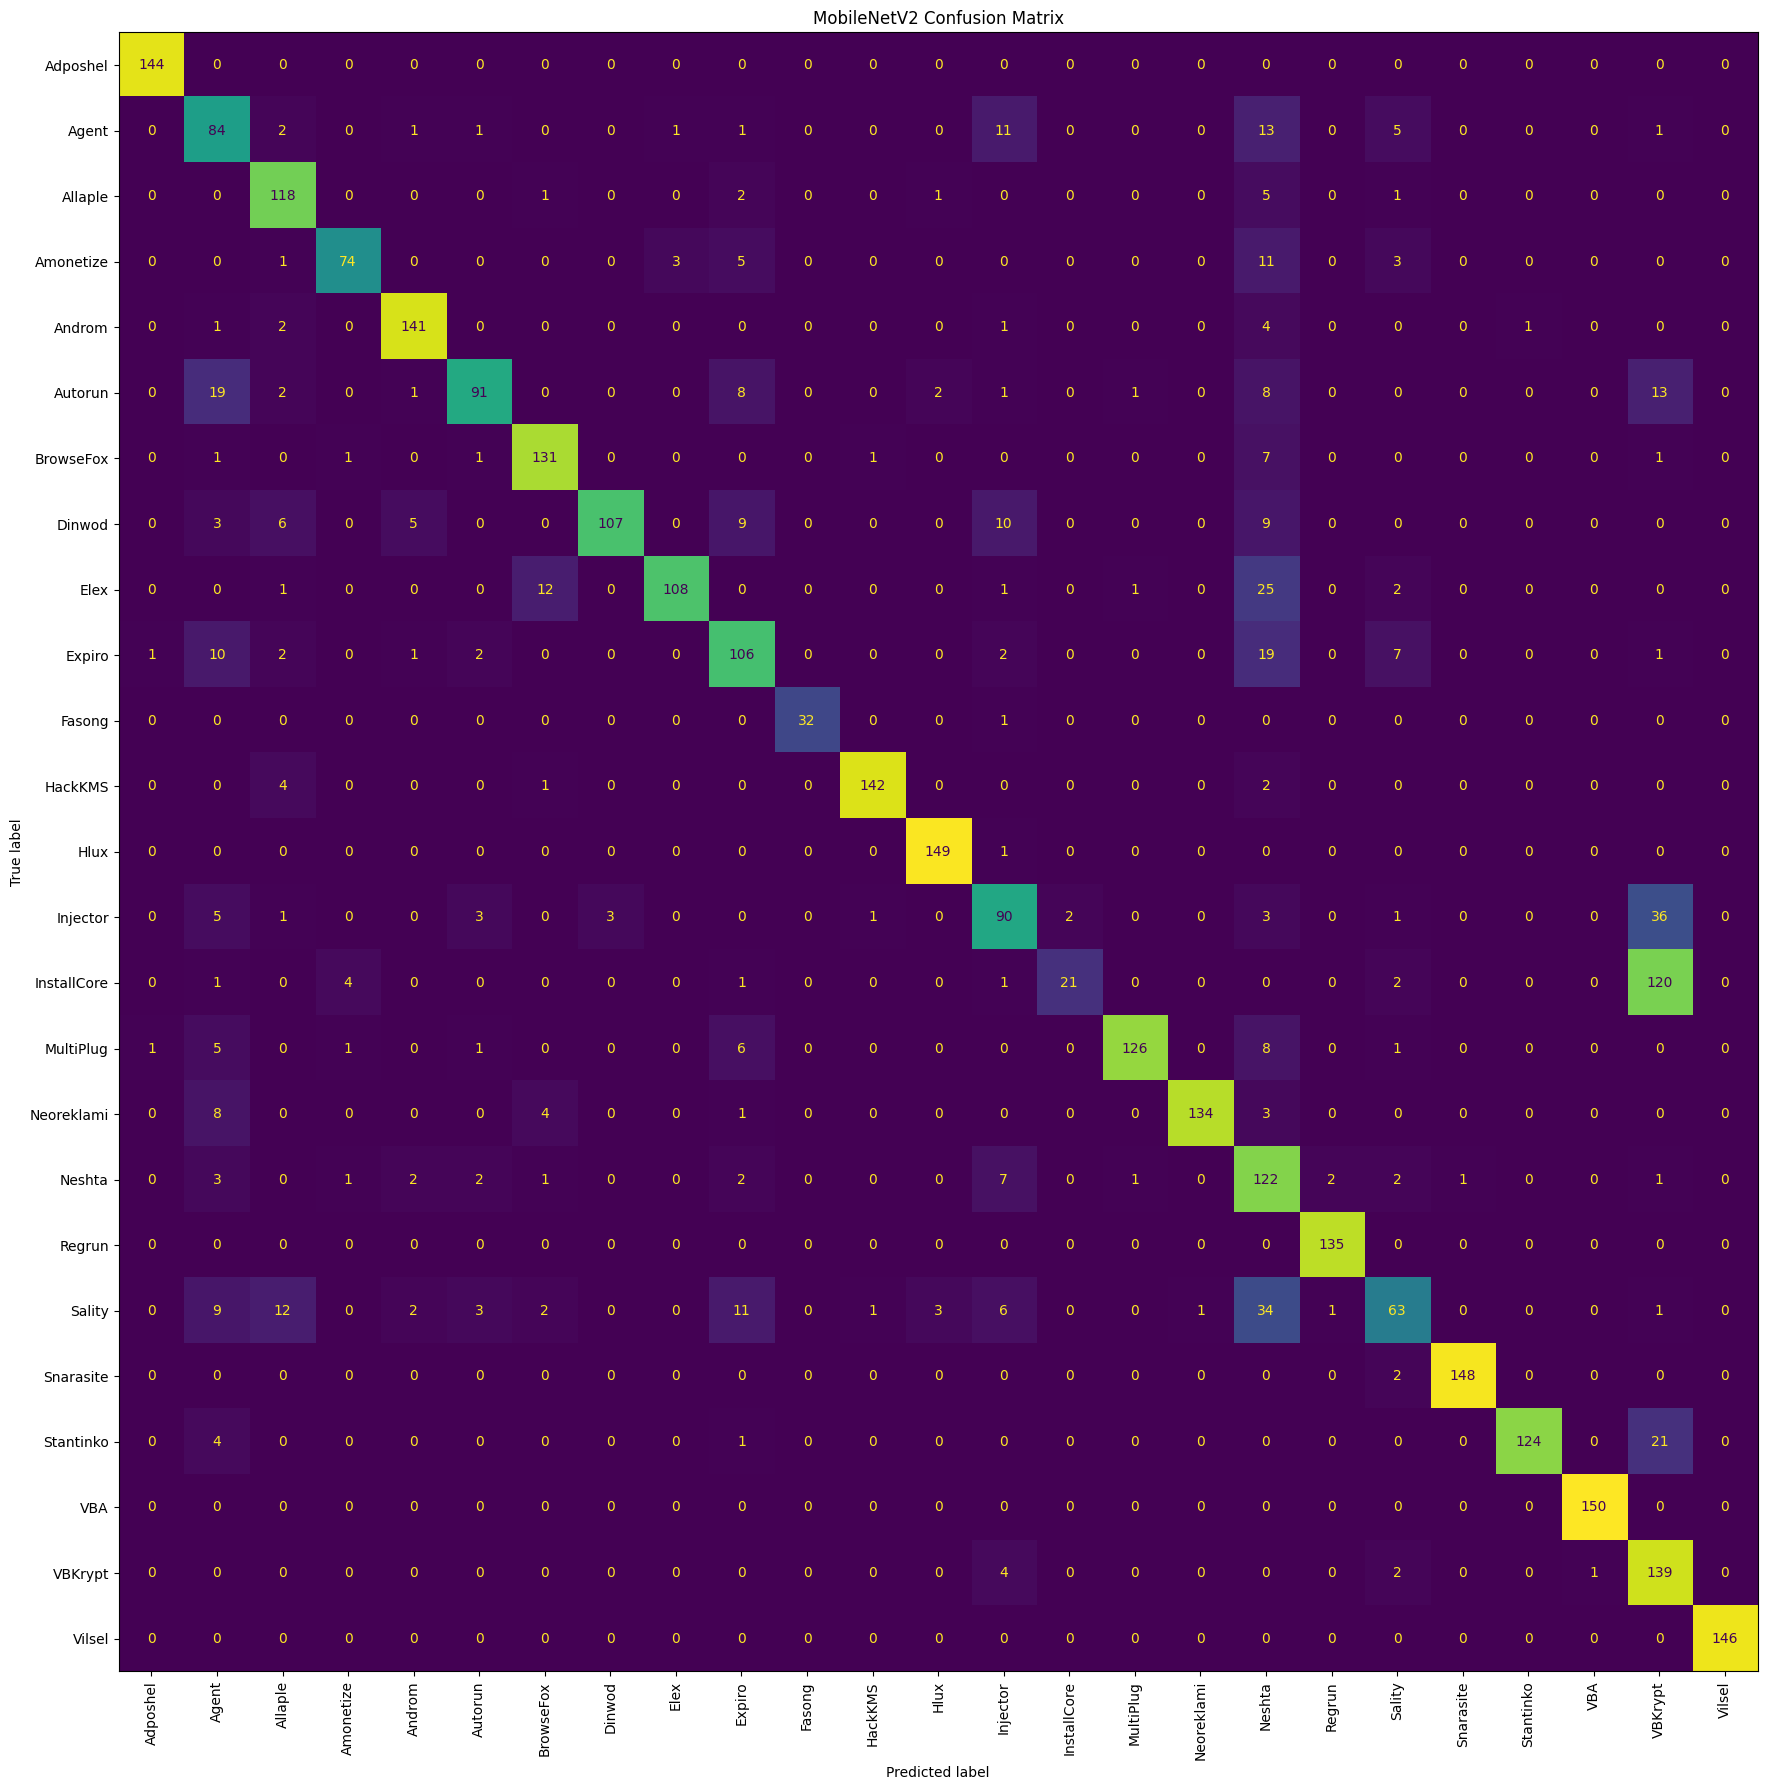

In [99]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(18, 18))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display_cm.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

plt.title("MobileNetV2 Confusion Matrix")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "mobilenetv2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
# Combine MobileNetV2 training stages

stage1_df = pd.DataFrame(
    mobilenet_stage1_history.history
)

stage1_df["Epoch"] = np.arange(
    1,
    len(stage1_df) + 1
)

stage1_df["Stage"] = "Frozen"


stage2_df = pd.DataFrame(
    mobilenet_stage2_history.history
)

stage2_df["Epoch"] = np.arange(
    11,
    11 + len(stage2_df)
)

stage2_df["Stage"] = "Fine-tuning"


complete_history_df = pd.concat(
    [stage1_df, stage2_df],
    ignore_index=True
)


complete_history_df.to_csv(
    OUTPUT_DIR / "mobilenetv2_training_history.csv",
    index=False
)


display(complete_history_df.tail())

,accuracy,loss,val_accuracy,val_loss,learning_rate,Epoch,Stage
18,0.931847,0.234768,0.765848,0.821657,1.000000e-05,14,Fine-tuning
19,0.931705,0.238240,0.754426,0.773440,1.000000e-05,15,Fine-tuning
20,0.940420,0.205475,0.777841,0.768155,2.000000e-06,16,Fine-tuning
21,0.940420,0.196793,0.770417,0.731017,2.000000e-06,17,Fine-tuning
22,0.941277,0.194182,0.771559,0.732446,4.000000e-07,18,Fine-tuning


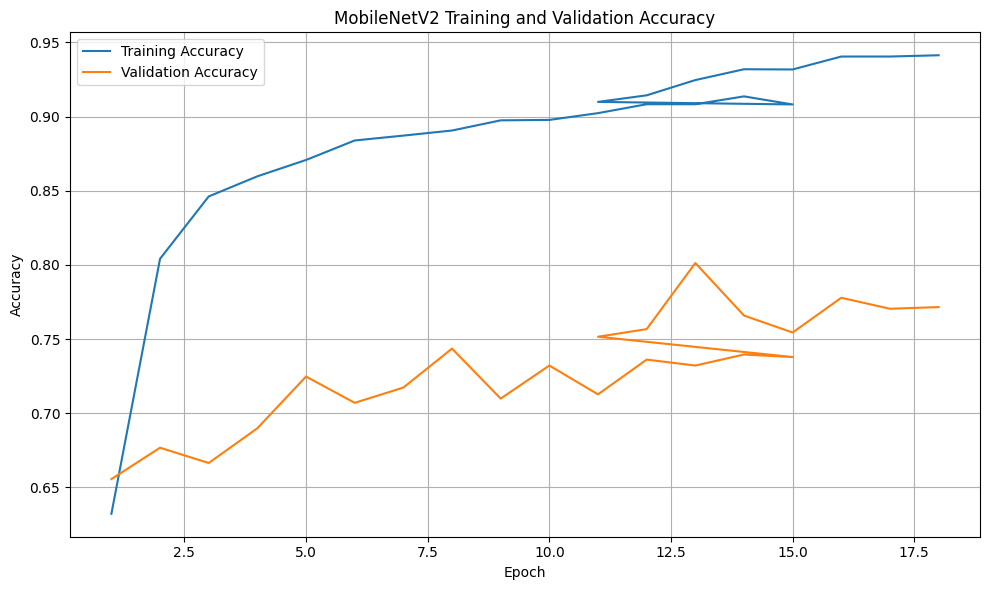

In [101]:
plt.figure(figsize=(10, 6))

plt.plot(
    complete_history_df["Epoch"],
    complete_history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    complete_history_df["Epoch"],
    complete_history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "mobilenetv2_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

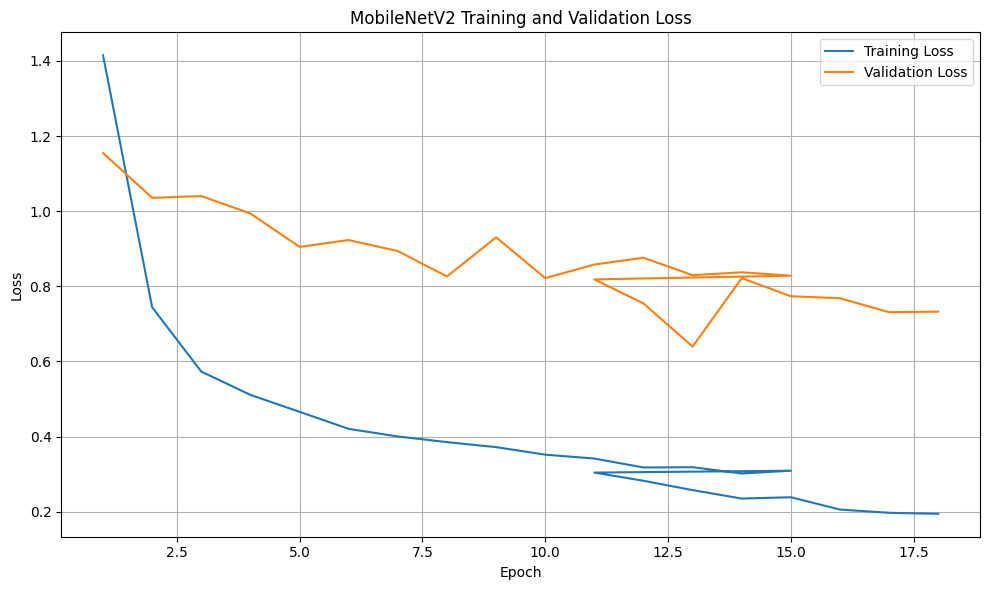

In [102]:
plt.figure(figsize=(10, 6))

plt.plot(
    complete_history_df["Epoch"],
    complete_history_df["loss"],
    label="Training Loss"
)

plt.plot(
    complete_history_df["Epoch"],
    complete_history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "mobilenetv2_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [104]:

import shutil
ZIP_PATH = shutil.make_archive(
    "/kaggle/working/mobilenetv2_complete_results",
    "zip",
    OUTPUT_DIR
)

print("ZIP created successfully:")
print(ZIP_PATH)

ZIP created successfully:
/kaggle/working/mobilenetv2_complete_results.zip
